# Q5 six-year future projections

This notebook generates six annual model-based projections of the survey-weighted frequent sport volunteering rate for each `borough × age group × activity level` cell.

The forecasting method and hyperparameters were selected previously using the Q5 model-comparison notebook. No model or hyperparameter selection is reopened here.

The selected model is refitted using all available historical waves and then applied recursively. After the first forecast year, each year's projection becomes the lagged input for the following year.

The notebook also evaluates recursive forecast behaviour, constructs empirical projection intervals, examines structural sensitivity across the previously evaluated model families, and derives projected activity-level gaps within each age group.

> **Interpretation boundary.**
> The results are conditional model-based projections. They do not incorporate future policy, demographic or behavioural shocks, and they should not be interpreted as causal effects or precise population forecasts.

## 1 — Load historical data and model-selection outputs

The complete historical panel and the outputs from the model-comparison notebook are loaded first.

The selected forecasting method, tuned parameters, feature definitions and prediction bounds are read from the saved model-selection summary. This prevents the forecasting analysis from manually redefining or reselecting the model.

In [20]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


pd.set_option(
    "display.max_columns",
    80,
)

PROJECT_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code"
)

PANEL_PATH = (
    PROJECT_DIR
    / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
)

MODEL_OUTPUT_DIR = (
    PROJECT_DIR
    / "q5_model_comparison_outputs"
)

MODEL_SUMMARY_PATH = (
    MODEL_OUTPUT_DIR
    / "q5_model_selection_summary.json"
)

MODEL_TUNING_PATH = (
    MODEL_OUTPUT_DIR
    / "tables"
    / "q5_model_tuning.csv"
)

VALIDATION_PREDICTIONS_PATH = (
    MODEL_OUTPUT_DIR
    / "tables"
    / "q5_validation_predictions.csv"
)

TEST_PREDICTIONS_PATH = (
    MODEL_OUTPUT_DIR
    / "tables"
    / "q5_test_predictions.csv"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "q5_future_forecasting_outputs"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

required_paths = [
    PANEL_PATH,
    MODEL_SUMMARY_PATH,
    MODEL_TUNING_PATH,
    VALIDATION_PREDICTIONS_PATH,
    TEST_PREDICTIONS_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required input: {path}"
        )

q5_panel = pd.read_csv(
    PANEL_PATH,
    low_memory=False,
)

with MODEL_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_selection_summary = json.load(
        file
    )

tuning_table = pd.read_csv(
    MODEL_TUNING_PATH
)

validation_predictions = pd.read_csv(
    VALIDATION_PREDICTIONS_PATH,
    low_memory=False,
)

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_PATH,
    low_memory=False,
)

TARGET = model_selection_summary[
    "target"
]

SELECTED_MODEL = model_selection_summary[
    "selected_model"
]

SELECTED_TUNED_PARAMETERS = (
    model_selection_summary[
        "tuned_parameters"
    ]
)

SELECTED_FIXED_PARAMETERS = (
    model_selection_summary.get(
        "fixed_parameters",
        {},
    )
)

NUMERIC_FEATURES = model_selection_summary[
    "numeric_features"
]

CATEGORICAL_FEATURES = (
    model_selection_summary[
        "categorical_features"
    ]
)

MODEL_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

RANDOM_STATE = int(
    model_selection_summary[
        "random_state"
    ]
)

(
    PREDICTION_LOWER,
    PREDICTION_UPPER,
) = model_selection_summary[
    "prediction_bounds"
]

HISTORICAL_YEARS = sorted(
    pd.to_numeric(
        q5_panel["year"],
        errors="coerce",
    )
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

LAST_HISTORICAL_YEAR = max(
    HISTORICAL_YEARS
)

FUTURE_YEARS = list(
    range(
        LAST_HISTORICAL_YEAR + 1,
        LAST_HISTORICAL_YEAR + 7,
    )
)

TIME_TREND_BASE_YEAR = min(
    model_selection_summary[
        "training_years"
    ]
)

LAG_FEATURE = (
    f"{TARGET}_lag1"
)

N_SIMULATIONS = 500
SIMULATION_BATCH_SIZE = 50

INTERVAL_ALPHA = 0.10

MIN_RESIDUAL_POOL_SIZE = 20

if LAG_FEATURE not in NUMERIC_FEATURES:
    raise ValueError(
        "The saved feature specification does not contain the expected lag"
    )

if LAST_HISTORICAL_YEAR != int(
    model_selection_summary[
        "test_year"
    ]
):
    raise ValueError(
        "The final historical year does not match the model-comparison test year"
    )

print(
    f"Selected model: "
    f"{SELECTED_MODEL}"
)

print(
    f"Selected tuned parameters: "
    f"{SELECTED_TUNED_PARAMETERS}"
)

print(
    f"Historical years: "
    f"{HISTORICAL_YEARS}"
)

print(
    f"Future years: "
    f"{FUTURE_YEARS}"
)

Selected model: Gradient Boosting
Selected tuned parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 150}
Historical years: [3, 4, 5, 6, 7, 8]
Future years: [9, 10, 11, 12, 13, 14]


## 2 — Reconstruct the historical modelling features

The historical modelling features are reconstructed using the same definitions as in the model-comparison analysis.

The one-year lag is created within each complete borough–age–activity series before unavailable targets are removed. This preserves calendar-year spacing and prevents a missing year from
being replaced by an older observation.

Only observed target rows are used when the final model is refitted. Reliability variables remain descriptive metadata and are not included as behavioural predictors.

In [21]:
def parse_nullable_boolean(
    series,
):
    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return text_values.map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    ).astype("boolean")


required_columns = [
    "series_id",
    "year",
    "LA_2023",
    "age_group_code",
    "age_group",
    "activity_level_3cat",
    "activity_level_3cat_label",
    TARGET,
    "effective_n_parent_cell",
    "small_cell",
]

missing_columns = [
    column
    for column in required_columns
    if column not in q5_panel.columns
]

if missing_columns:
    raise ValueError(
        f"Missing panel columns: "
        f"{missing_columns}"
    )

numeric_columns = [
    "year",
    "LA_2023",
    "age_group_code",
    "activity_level_3cat",
    TARGET,
    "effective_n_parent_cell",
]

for column in numeric_columns:
    q5_panel[column] = pd.to_numeric(
        q5_panel[column],
        errors="coerce",
    )

q5_panel["small_cell"] = (
    parse_nullable_boolean(
        q5_panel[
            "small_cell"
        ]
    )
)

q5_model_panel = (
    q5_panel
    .sort_values(
        [
            "series_id",
            "year",
        ]
    )
    .reset_index(drop=True)
)

q5_model_panel[
    LAG_FEATURE
] = (
    q5_model_panel
    .groupby(
        "series_id",
        sort=False,
    )[TARGET]
    .shift(1)
)

q5_model_panel[
    "lag_1_available"
] = q5_model_panel[
    LAG_FEATURE
].notna()

q5_model_panel[
    "lag_1_missing"
] = (
    ~q5_model_panel[
        "lag_1_available"
    ]
).astype(int)

q5_model_panel[
    "time_trend"
] = (
    q5_model_panel[
        "year"
    ]
    - TIME_TREND_BASE_YEAR
)

q5_model_panel[
    "borough_category"
] = (
    q5_model_panel[
        "LA_2023"
    ]
    .astype("Int64")
    .astype("string")
)

q5_model_panel[
    "age_activity_group"
] = (
    q5_model_panel[
        "age_group"
    ].astype("string")
    + "__"
    + q5_model_panel[
        "activity_level_3cat_label"
    ].astype("string")
)

q5_model_panel[
    "target_available"
] = q5_model_panel[
    TARGET
].notna()

final_training_data = (
    q5_model_panel.loc[
        q5_model_panel[
            "target_available"
        ]
    ]
    .copy()
)

missing_model_features = [
    feature
    for feature in MODEL_FEATURES
    if feature not in final_training_data.columns
]

if missing_model_features:
    raise ValueError(
        f"Missing modelling features: "
        f"{missing_model_features}"
    )

print(
    f"Historical training rows: "
    f"{len(final_training_data):,}"
)

print(
    f"Historical series: "
    f"{q5_model_panel['series_id'].nunique():,}"
)

print(
    f"Observed target years: "
    f"{sorted(final_training_data['year'].unique())}"
)

Historical training rows: 4,127
Historical series: 768
Observed target years: [3, 4, 5, 6, 7, 8]


## 3 — Recreate the forecasting pipelines

The same preprocessing and estimator definitions used in the model-comparison analysis are reconstructed here.

For structural sensitivity only, the previously selected hyperparameters for Ridge Regression, Random Forest and Gradient Boosting are recovered from the saved Year 7 tuning results. 

In [22]:
def build_model(
    model_name,
    parameters,
    numeric_features,
    categorical_features,
    fixed_parameters=None,
):
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        )
    ]

    if model_name == "Ridge Regression":
        numeric_steps.append(
            (
                "scale",
                StandardScaler(),
            )
        )

    categorical_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    numeric_steps
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    categorical_steps
                ),
                categorical_features,
            ),
        ]
    )

    estimator_parameters = dict(
        parameters
    )

    estimator_parameters.update(
        fixed_parameters or {}
    )

    if model_name == "Ridge Regression":
        estimator = Ridge(
            **estimator_parameters
        )

    elif model_name == "Random Forest":
        estimator_parameters.setdefault(
            "random_state",
            RANDOM_STATE,
        )

        estimator_parameters.setdefault(
            "n_jobs",
            -1,
        )

        estimator = RandomForestRegressor(
            **estimator_parameters
        )

    elif model_name == "Gradient Boosting":
        estimator_parameters.setdefault(
            "random_state",
            RANDOM_STATE,
        )

        estimator_parameters.setdefault(
            "loss",
            "huber",
        )

        estimator = GradientBoostingRegressor(
            **estimator_parameters
        )

    else:
        raise ValueError(
            f"Unknown machine-learning model: "
            f"{model_name}"
        )

    return Pipeline(
        steps=[
            (
                "preprocess",
                preprocessing,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )


def extract_best_parameters(
    model_name,
):
    model_rows = tuning_table.loc[
        tuning_table[
            "model"
        ].eq(
            model_name
        )
    ].copy()

    if model_rows.empty:
        raise ValueError(
            f"No tuning rows found for "
            f"{model_name}"
        )

    best_row = (
        model_rows
        .sort_values(
            [
                "validation_mae",
                "validation_rmse",
                "validation_clip_rate",
                "candidate_id",
            ]
        )
        .iloc[0]
    )

    return json.loads(
        best_row[
            "parameters"
        ]
    )


BEST_PARAMETERS = {
    model_name: (
        extract_best_parameters(
            model_name
        )
    )
    for model_name in [
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
    ]
}


def fixed_parameters_for_model(
    model_name,
):
    if model_name == SELECTED_MODEL:
        return dict(
            SELECTED_FIXED_PARAMETERS
        )

    if model_name == "Gradient Boosting":
        return {
            "loss": "huber",
        }

    return {}


if SELECTED_MODEL != "Naive baseline":
    if (
        BEST_PARAMETERS[
            SELECTED_MODEL
        ]
        != SELECTED_TUNED_PARAMETERS
    ):
        raise ValueError(
            "The selected parameters do not match the saved tuning results"
        )

for model_name, parameters in (
    BEST_PARAMETERS.items()
):
    print(
        f"{model_name}: "
        f"{parameters}"
    )

Ridge Regression: {'alpha': 10.0}
Random Forest: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 30, 'n_estimators': 400}
Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 150}


## 4 — Refit the selected model on all historical waves

The selected forecasting method is refitted using every available observed target from Years 3–8. This uses the maximum amount of historical information available before generating future projections.

No effective-sample-size training weight is applied because the unweighted specification was retained as the primary model in the model-comparison analysis.

In [23]:
if SELECTED_MODEL == "Naive baseline":
    selected_fitted_model = None

else:
    selected_fitted_model = build_model(
        model_name=SELECTED_MODEL,
        parameters=(
            SELECTED_TUNED_PARAMETERS
        ),
        numeric_features=(
            NUMERIC_FEATURES
        ),
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        fixed_parameters=(
            SELECTED_FIXED_PARAMETERS
        ),
    )

    selected_fitted_model.fit(
        final_training_data[
            MODEL_FEATURES
        ],
        final_training_data[
            TARGET
        ],
    )

print(
    f"Refitted forecasting method: "
    f"{SELECTED_MODEL}"
)

print(
    f"Historical training rows used: "
    f"{len(final_training_data):,}"
)

Refitted forecasting method: Gradient Boosting
Historical training rows used: 4,127


## 5 — Construct the future series grid and historical reliability metadata

The future projection universe contains the same 768 borough–age–activity series observed in the historical complete panel.

Historical reliability is summarised separately for each series using the median effective sample size, the number of observed historical targets and the proportion of historical cells flagged as small. These reliability summaries are not forecasting predictors. They are retained to identify projections that originate from historically sparse survey cells.

The observed Year 8 rate is also attached as the initial lag and as the historical baseline for percentage-point change calculations.

In [24]:
series_columns = [
    "series_id",
    "LA_2023",
    "age_group_code",
    "age_group",
    "activity_level_3cat",
    "activity_level_3cat_label",
]

series_frame = (
    q5_model_panel[
        series_columns
    ]
    .drop_duplicates(
        "series_id"
    )
    .sort_values(
        "series_id"
    )
    .reset_index(drop=True)
)

year8_baseline = (
    q5_model_panel.loc[
        q5_model_panel[
            "year"
        ].eq(
            LAST_HISTORICAL_YEAR
        ),
        [
            "series_id",
            TARGET,
        ],
    ]
    .rename(
        columns={
            TARGET: (
                "year8_observed_rate"
            )
        }
    )
)

historical_reliability = (
    q5_model_panel
    .groupby(
        "series_id",
        as_index=False,
    )
    .agg(
        historical_observed_years=(
            TARGET,
            "count",
        ),
        historical_effective_n_median=(
            "effective_n_parent_cell",
            "median",
        ),
        historical_small_cell_share=(
            "small_cell",
            lambda values: (
                values
                .astype("Float64")
                .mean()
            ),
        ),
    )
)

series_frame = (
    series_frame
    .merge(
        year8_baseline,
        on="series_id",
        how="left",
    )
    .merge(
        historical_reliability,
        on="series_id",
        how="left",
    )
)

series_frame[
    "initial_year8_lag_observed"
] = series_frame[
    "year8_observed_rate"
].notna()

series_frame[
    "historical_reliability_band"
] = pd.cut(
    series_frame[
        "historical_effective_n_median"
    ],
    bins=[
        -np.inf,
        5,
        10,
        30,
        np.inf,
    ],
    labels=[
        "below_5",
        "5_to_below_10",
        "10_to_below_30",
        "30_or_above",
    ],
    right=False,
).astype(
    "string"
).fillna(
    "unknown"
)

if len(series_frame) != 768:
    raise ValueError(
        "The future universe must contain 768 borough-age-activity series"
    )

print(
    f"Future series: "
    f"{len(series_frame):,}"
)

print(
    f"Series with observed Year 8 lag: "
    f"{series_frame['initial_year8_lag_observed'].sum():,}"
)

print(
    f"Series without observed Year 8 lag: "
    f"{(~series_frame['initial_year8_lag_observed']).sum():,}"
)

display(
    series_frame[
        "historical_reliability_band"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "historical_reliability_band"
    )
    .reset_index(
        name="series"
    )
)

Future series: 768
Series with observed Year 8 lag: 716
Series without observed Year 8 lag: 52


,historical_reliability_band,series
0,below_5,373
1,5_to_below_10,172
2,10_to_below_30,172
3,30_or_above,41
4,unknown,10


## 6 — Generate recursive point projections

For the first forecast year, the lag is the observed Year 8 rate when available. If the Year 8 rate is unavailable, the lag remains missing and is handled by the same median-imputation and missing-indicator mechanism used during model development.

From the second forecast year onwards, the previous model projection is used as the lagged input.

The source of every lag is retained explicitly so that projections starting without an observed Year 8 value can be identified.

In [25]:
def make_forecast_rows(
    series_data,
    year,
    lag_values,
    lag_missing,
):
    rows = series_data.copy()

    rows["year"] = int(
        year
    )

    rows[
        "forecast_horizon"
    ] = int(
        year
        - LAST_HISTORICAL_YEAR
    )

    rows[
        LAG_FEATURE
    ] = np.asarray(
        lag_values,
        dtype=float,
    )

    rows[
        "lag_1_missing"
    ] = (
        np.asarray(
            lag_missing,
            dtype=bool,
        )
        .astype(int)
    )

    rows[
        "time_trend"
    ] = (
        rows["year"]
        - TIME_TREND_BASE_YEAR
    )

    rows[
        "borough_category"
    ] = (
        rows[
            "LA_2023"
        ]
        .astype("Int64")
        .astype("string")
    )

    rows[
        "age_activity_group"
    ] = (
        rows[
            "age_group"
        ].astype("string")
        + "__"
        + rows[
            "activity_level_3cat_label"
        ].astype("string")
    )

    return rows


def predict_with_model(
    model_name,
    model,
    data,
):
    if model_name == "Naive baseline":
        raw_prediction = data[
            LAG_FEATURE
        ].to_numpy(
            dtype=float
        )

    else:
        raw_prediction = np.asarray(
            model.predict(
                data[
                    MODEL_FEATURES
                ]
            ),
            dtype=float,
        ).reshape(-1)

    prediction = np.clip(
        raw_prediction,
        PREDICTION_LOWER,
        PREDICTION_UPPER,
    )

    return (
        prediction,
        raw_prediction,
    )


def recursive_forecast(
    model_name,
    model,
    series_data,
    future_years,
):
    lag_values = series_data[
        "year8_observed_rate"
    ].to_numpy(
        dtype=float
    )

    lag_missing = np.isnan(
        lag_values
    )

    forecast_parts = []

    for index, year in enumerate(
        future_years
    ):
        rows = make_forecast_rows(
            series_data=series_data,
            year=year,
            lag_values=lag_values,
            lag_missing=lag_missing,
        )

        (
            prediction,
            raw_prediction,
        ) = predict_with_model(
            model_name=model_name,
            model=model,
            data=rows,
        )

        rows[
            "raw_predicted_rate"
        ] = raw_prediction

        rows[
            "predicted_rate"
        ] = prediction

        rows[
            "was_clipped"
        ] = (
            np.isfinite(
                raw_prediction
            )
            & (
                (
                    raw_prediction
                    < PREDICTION_LOWER
                )
                | (
                    raw_prediction
                    > PREDICTION_UPPER
                )
            )
        )

        if index == 0:
            rows[
                "lag_source"
            ] = np.where(
                lag_missing,
                "missing_year8",
                "observed_year8",
            )

        else:
            rows[
                "lag_source"
            ] = np.where(
                lag_missing,
                (
                    "unavailable_previous_"
                    "projection"
                ),
                "predicted_previous_year",
            )

        forecast_parts.append(
            rows
        )

        lag_values = prediction

        lag_missing = np.isnan(
            prediction
        )

    return (
        pd.concat(
            forecast_parts,
            ignore_index=True,
        )
        .sort_values(
            [
                "year",
                "series_id",
            ]
        )
        .reset_index(drop=True)
    )


future_projections = recursive_forecast(
    model_name=SELECTED_MODEL,
    model=selected_fitted_model,
    series_data=series_frame,
    future_years=FUTURE_YEARS,
)

future_projections[
    "predicted_rate_pp"
] = (
    100
    * future_projections[
        "predicted_rate"
    ]
)

future_projections[
    "change_from_year8_pp"
] = (
    100
    * (
        future_projections[
            "predicted_rate"
        ]
        - future_projections[
            "year8_observed_rate"
        ]
    )
)

point_forecast_summary = (
    future_projections
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        cells=(
            "series_id",
            "count",
        ),
        mean_rate=(
            "predicted_rate",
            "mean",
        ),
        median_rate=(
            "predicted_rate",
            "median",
        ),
        min_rate=(
            "predicted_rate",
            "min",
        ),
        max_rate=(
            "predicted_rate",
            "max",
        ),
        clipped_predictions=(
            "was_clipped",
            "sum",
        ),
    )
)

display(
    point_forecast_summary
)

,year,cells,mean_rate,median_rate,min_rate,max_rate,clipped_predictions
0,9,768,0.074646,0.069092,0.028773,0.154844,0
1,10,768,0.086360,0.075718,0.052868,0.153260,0
2,11,768,0.086286,0.075718,0.052868,0.153260,0
3,12,768,0.086293,0.075718,0.052868,0.153260,0
4,13,768,0.086286,0.075718,0.052868,0.153260,0
5,14,768,0.086293,0.075718,0.052868,0.153260,0


## 7 — Diagnose recursive forecast error using historical origins

The original model comparison evaluated one-year-ahead prediction, where the previous year's observed rate was available whenever the lag existed.

Future multi-year projections are different because model projections become lagged inputs for later horizons. A recursive historical diagnostic is therefore performed.

Several historical forecast origins are used. At each origin the frozen selected model specification is refitted using only earlier years and then projected recursively to the end of the observed period.

This diagnostic does not reopen model selection. Because only six historical waves are available, it provides evidence for horizons up to four years rather than a full six-year independent backtest.

In [26]:
def score_forecast(
    actual,
    predicted,
):
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[
        valid
    ]

    predicted = predicted[
        valid
    ]

    if len(actual) == 0:
        return {
            "observations": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "mean_error": np.nan,
        }

    if (
        len(actual) < 2
        or np.isclose(
            np.var(actual),
            0,
        )
    ):
        r2 = np.nan

    else:
        r2 = r2_score(
            actual,
            predicted,
        )

    return {
        "observations": len(
            actual
        ),
        "mae": mean_absolute_error(
            actual,
            predicted,
        ),
        "rmse": np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        ),
        "r2": r2,
        "mean_error": np.mean(
            predicted - actual
        ),
    }


def recursive_backtest_origin(
    origin_year,
):
    train = q5_model_panel.loc[
        q5_model_panel[
            "target_available"
        ]
        & q5_model_panel[
            "year"
        ].lt(
            origin_year
        )
    ].copy()

    if SELECTED_MODEL == "Naive baseline":
        fitted_model = None

    else:
        fitted_model = build_model(
            model_name=(
                SELECTED_MODEL
            ),
            parameters=(
                SELECTED_TUNED_PARAMETERS
            ),
            numeric_features=(
                NUMERIC_FEATURES
            ),
            categorical_features=(
                CATEGORICAL_FEATURES
            ),
            fixed_parameters=(
                SELECTED_FIXED_PARAMETERS
            ),
        )

        fitted_model.fit(
            train[
                MODEL_FEATURES
            ],
            train[
                TARGET
            ],
        )

    first_year_lag = (
        q5_model_panel.loc[
            q5_model_panel[
                "year"
            ].eq(
                origin_year
            ),
            [
                "series_id",
                LAG_FEATURE,
            ],
        ]
        .set_index(
            "series_id"
        )[LAG_FEATURE]
        .reindex(
            series_frame[
                "series_id"
            ]
        )
        .to_numpy(
            dtype=float
        )
    )

    lag_values = first_year_lag

    lag_missing = np.isnan(
        lag_values
    )

    output_parts = []

    for forecast_year in range(
        origin_year,
        LAST_HISTORICAL_YEAR + 1,
    ):
        rows = make_forecast_rows(
            series_data=series_frame,
            year=forecast_year,
            lag_values=lag_values,
            lag_missing=lag_missing,
        )

        (
            prediction,
            raw_prediction,
        ) = predict_with_model(
            model_name=SELECTED_MODEL,
            model=fitted_model,
            data=rows,
        )

        actual = (
            q5_model_panel.loc[
                q5_model_panel[
                    "year"
                ].eq(
                    forecast_year
                ),
                [
                    "series_id",
                    TARGET,
                ],
            ]
            .set_index(
                "series_id"
            )[TARGET]
            .reindex(
                series_frame[
                    "series_id"
                ]
            )
            .to_numpy(
                dtype=float
            )
        )

        output = rows[
            series_columns
        ].copy()

        output[
            "origin_year"
        ] = origin_year

        output[
            "forecast_year"
        ] = forecast_year

        output[
            "horizon"
        ] = (
            forecast_year
            - origin_year
            + 1
        )

        output[
            "actual_rate"
        ] = actual

        output[
            "predicted_rate"
        ] = prediction

        output[
            "raw_predicted_rate"
        ] = raw_prediction

        output_parts.append(
            output
        )

        lag_values = prediction

        lag_missing = np.isnan(
            prediction
        )

    return pd.concat(
        output_parts,
        ignore_index=True,
    )


BACKTEST_ORIGINS = list(
    range(
        min(HISTORICAL_YEARS) + 2,
        LAST_HISTORICAL_YEAR + 1,
    )
)

recursive_backtest_predictions = (
    pd.concat(
        [
            recursive_backtest_origin(
                origin
            )
            for origin in BACKTEST_ORIGINS
        ],
        ignore_index=True,
    )
)

origin_metric_rows = []

for (
    origin_year,
    horizon,
), group in (
    recursive_backtest_predictions
    .groupby(
        [
            "origin_year",
            "horizon",
        ]
    )
):
    metrics = score_forecast(
        actual=group[
            "actual_rate"
        ],
        predicted=group[
            "predicted_rate"
        ],
    )

    origin_metric_rows.append(
        {
            "origin_year": (
                origin_year
            ),
            "horizon": (
                horizon
            ),
            "forecast_year": int(
                group[
                    "forecast_year"
                ].iloc[0]
            ),
            **metrics,
        }
    )

recursive_diagnostic_by_origin = (
    pd.DataFrame(
        origin_metric_rows
    )
)

horizon_metric_rows = []

for horizon, group in (
    recursive_backtest_predictions
    .groupby(
        "horizon"
    )
):
    metrics = score_forecast(
        actual=group[
            "actual_rate"
        ],
        predicted=group[
            "predicted_rate"
        ],
    )

    horizon_metric_rows.append(
        {
            "horizon": horizon,
            "origins": (
                group[
                    "origin_year"
                ].nunique()
            ),
            **metrics,
        }
    )

recursive_diagnostic_by_horizon = (
    pd.DataFrame(
        horizon_metric_rows
    )
)

display(
    recursive_diagnostic_by_horizon
)

,horizon,origins,observations,mae,rmse,r2,mean_error
0,1,4,2828,0.081868,0.137184,-0.006928,-0.027075
1,2,3,2133,0.081430,0.131348,0.029998,-0.017115
2,3,2,1429,0.085162,0.134329,0.025988,-0.022882
3,4,1,716,0.087166,0.146953,-0.045046,-0.044111


## 8 — Build empirical out-of-sample residual pools

Empirical predictive uncertainty is based on the selected model's out-of-sample residuals from Year 7 validation and Year 8 independent testing.

Residuals are defined as: `observed rate - predicted rate`.

The residuals are separated where possible by historical reliability band and by lag availability. When a stratum contains too few observations, the procedure falls back to a broader residual pool.

This retains the larger errors observed among sparse survey cells without treating effective sample size as a behavioural predictor.

The residual distribution represents observed forecasting error. It is not a formal survey-sampling variance estimate and does not capture all sources of future uncertainty.

In [27]:
PREDICTION_COLUMN = (
    "predicted_frequent_volunteer_rate"
)


def parse_prediction_boolean(
    series,
):
    if pd.api.types.is_bool_dtype(
        series
    ):
        return series.astype(
            bool
        )

    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return (
        text_values
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


residual_source = pd.concat(
    [
        validation_predictions.loc[
            validation_predictions[
                "model"
            ].eq(
                SELECTED_MODEL
            )
        ].copy(),
        test_predictions.loc[
            test_predictions[
                "model"
            ].eq(
                SELECTED_MODEL
            )
        ].copy(),
    ],
    ignore_index=True,
)

residual_source[
    "effective_n_parent_cell"
] = pd.to_numeric(
    residual_source[
        "effective_n_parent_cell"
    ],
    errors="coerce",
)

residual_source[
    "lag_1_available"
] = parse_prediction_boolean(
    residual_source[
        "lag_1_available"
    ]
)

residual_source[
    "residual"
] = (
    pd.to_numeric(
        residual_source[
            TARGET
        ],
        errors="coerce",
    )
    - pd.to_numeric(
        residual_source[
            PREDICTION_COLUMN
        ],
        errors="coerce",
    )
)

residual_source[
    "residual_lag_missing"
] = (
    ~residual_source[
        "lag_1_available"
    ]
)

residual_source[
    "residual_reliability_band"
] = pd.cut(
    residual_source[
        "effective_n_parent_cell"
    ],
    bins=[
        -np.inf,
        5,
        10,
        30,
        np.inf,
    ],
    labels=[
        "below_5",
        "5_to_below_10",
        "10_to_below_30",
        "30_or_above",
    ],
    right=False,
).astype(
    "string"
).fillna(
    "unknown"
)

residual_source = (
    residual_source.loc[
        residual_source[
            "residual"
        ].notna()
    ]
    .copy()
)


def build_residual_pools(
    data,
):
    pools = {}

    pools[
        ("global",)
    ] = data[
        "residual"
    ].to_numpy(
        dtype=float
    )

    for (
        lag_missing,
        group,
    ) in data.groupby(
        "residual_lag_missing",
        dropna=False,
    ):
        pools[
            (
                "lag",
                bool(
                    lag_missing
                ),
            )
        ] = group[
            "residual"
        ].to_numpy(
            dtype=float
        )

    for band, group in data.groupby(
        "residual_reliability_band",
        dropna=False,
    ):
        pools[
            (
                "band",
                str(band),
            )
        ] = group[
            "residual"
        ].to_numpy(
            dtype=float
        )

    for (
        band,
        lag_missing,
    ), group in data.groupby(
        [
            "residual_reliability_band",
            "residual_lag_missing",
        ],
        dropna=False,
    ):
        pools[
            (
                "band_lag",
                str(band),
                bool(
                    lag_missing
                ),
            )
        ] = group[
            "residual"
        ].to_numpy(
            dtype=float
        )

    return pools


RESIDUAL_POOLS = (
    build_residual_pools(
        residual_source
    )
)


def select_residual_pool(
    band,
    lag_missing,
):
    candidate_keys = [
        (
            "band_lag",
            str(band),
            bool(
                lag_missing
            ),
        ),
        (
            "lag",
            bool(
                lag_missing
            ),
        ),
        (
            "band",
            str(band),
        ),
        (
            "global",
        ),
    ]

    for key in candidate_keys:
        pool = RESIDUAL_POOLS.get(
            key,
            np.array(
                [],
                dtype=float,
            ),
        )

        if (
            len(pool)
            >= MIN_RESIDUAL_POOL_SIZE
            or key
            == ("global",)
        ):
            return pool

    return RESIDUAL_POOLS[
        ("global",)
    ]


residual_pool_diagnostics = (
    residual_source
    .groupby(
        [
            "residual_reliability_band",
            "residual_lag_missing",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        observations=(
            "residual",
            "size",
        ),
        mean_residual=(
            "residual",
            "mean",
        ),
        median_residual=(
            "residual",
            "median",
        ),
        q05_residual=(
            "residual",
            lambda values: (
                values.quantile(
                    0.05
                )
            ),
        ),
        q95_residual=(
            "residual",
            lambda values: (
                values.quantile(
                    0.95
                )
            ),
        ),
    )
)

display(
    residual_pool_diagnostics
)

,residual_reliability_band,residual_lag_missing,observations,mean_residual,median_residual,q05_residual,q95_residual
0,10_to_below_30,False,385,0.035888,0.025799,-0.066586,0.176537
1,30_or_above,False,148,0.044007,0.031877,-0.047103,0.163550
2,5_to_below_10,False,369,0.035209,-0.018716,-0.066586,0.280139
3,5_to_below_10,True,2,0.282594,0.282594,0.156615,0.408573
4,below_5,False,464,0.027657,-0.041811,-0.066586,0.390090
5,below_5,True,61,0.013907,-0.038541,-0.047155,0.449655


## 9 — Simulate recursive empirical projection intervals

A residual-based simulation is used to propagate observed one-year forecast error through the recursive six-year projection.

For each simulation:
1. the fitted model generates the conditional projection;
2. an out-of-sample residual is sampled from the appropriate empirical residual pool;
3. the resulting simulated rate is clipped to the valid `[0, 1]` interval;
4. that simulated rate becomes the lagged input for the next horizon.

The simulation is processed in batches to limit memory use.

The 5th and 95th percentiles form a 90% empirical projection interval. These intervals describe model-based predictive uncertainty rather than formal population confidence intervals.

In [28]:
def draw_residuals(
    rows,
    n_draws,
    rng,
):
    output = np.empty(
        (
            n_draws,
            len(rows),
        ),
        dtype=float,
    )

    bands = (
        rows[
            "historical_reliability_band"
        ]
        .astype("string")
        .fillna("unknown")
        .to_numpy()
    )

    lag_missing = (
        rows[
            "lag_1_missing"
        ]
        .astype(bool)
        .to_numpy()
    )

    combinations = pd.DataFrame(
        {
            "band": bands,
            "lag_missing": (
                lag_missing
            ),
        }
    )

    for (
        band,
        missing,
    ), group in combinations.groupby(
        [
            "band",
            "lag_missing",
        ],
        dropna=False,
    ):
        positions = group.index.to_numpy(
            dtype=int
        )

        pool = select_residual_pool(
            band=band,
            lag_missing=missing,
        )

        output[
            :,
            positions,
        ] = rng.choice(
            pool,
            size=(
                n_draws,
                len(
                    positions
                ),
            ),
            replace=True,
        )

    return output


if SELECTED_MODEL == "Naive baseline":
    raise ValueError(
        "The current residual simulation expects the selected fitted machine-learning model"
    )

n_series = len(
    series_frame
)

n_future_rows = (
    n_series
    * len(
        FUTURE_YEARS
    )
)

simulation_rates = np.full(
    (
        N_SIMULATIONS,
        n_future_rows,
    ),
    np.nan,
    dtype=np.float32,
)

rng = np.random.default_rng(
    RANDOM_STATE
)

initial_lag = series_frame[
    "year8_observed_rate"
].to_numpy(
    dtype=float
)

initial_missing = np.isnan(
    initial_lag
)

for batch_start in range(
    0,
    N_SIMULATIONS,
    SIMULATION_BATCH_SIZE,
):
    batch_end = min(
        batch_start
        + SIMULATION_BATCH_SIZE,
        N_SIMULATIONS,
    )

    batch_size = (
        batch_end
        - batch_start
    )

    lag_values = np.tile(
        initial_lag,
        (
            batch_size,
            1,
        ),
    )

    lag_missing = np.tile(
        initial_missing,
        (
            batch_size,
            1,
        ),
    )

    for (
        horizon_index,
        year,
    ) in enumerate(
        FUTURE_YEARS
    ):
        base_rows = (
            make_forecast_rows(
                series_data=(
                    series_frame
                ),
                year=year,
                lag_values=(
                    initial_lag
                ),
                lag_missing=(
                    initial_missing
                ),
            )
        )

        repeated_rows = pd.concat(
            [
                base_rows
            ]
            * batch_size,
            ignore_index=True,
        )

        repeated_rows[
            LAG_FEATURE
        ] = lag_values.reshape(
            -1
        )

        repeated_rows[
            "lag_1_missing"
        ] = (
            lag_missing
            .reshape(-1)
            .astype(int)
        )

        raw_prediction = np.asarray(
            selected_fitted_model.predict(
                repeated_rows[
                    MODEL_FEATURES
                ]
            ),
            dtype=float,
        )

        conditional_prediction = (
            np.clip(
                raw_prediction,
                PREDICTION_LOWER,
                PREDICTION_UPPER,
            )
            .reshape(
                batch_size,
                n_series,
            )
        )

        residual_rows = (
            base_rows.copy()
        )

        residual_rows[
            "lag_1_missing"
        ] = (
            lag_missing[
                0
            ]
            .astype(int)
        )

        residual_draws = (
            draw_residuals(
                rows=residual_rows,
                n_draws=batch_size,
                rng=rng,
            )
        )

        simulated_rate = np.clip(
            conditional_prediction
            + residual_draws,
            PREDICTION_LOWER,
            PREDICTION_UPPER,
        )

        start = (
            horizon_index
            * n_series
        )

        stop = (
            (
                horizon_index
                + 1
            )
            * n_series
        )

        simulation_rates[
            batch_start:batch_end,
            start:stop,
        ] = simulated_rate.astype(
            np.float32
        )

        lag_values = (
            simulated_rate
        )

        lag_missing = np.zeros_like(
            simulated_rate,
            dtype=bool,
        )

lower_quantile = (
    INTERVAL_ALPHA
    / 2
)

upper_quantile = (
    1
    - INTERVAL_ALPHA
    / 2
)

future_projections[
    "lower_90"
] = np.quantile(
    simulation_rates,
    lower_quantile,
    axis=0,
)

future_projections[
    "upper_90"
] = np.quantile(
    simulation_rates,
    upper_quantile,
    axis=0,
)

future_projections[
    "interval_width_pp"
] = (
    100
    * (
        future_projections[
            "upper_90"
        ]
        - future_projections[
            "lower_90"
        ]
    )
)

interval_summary = (
    future_projections
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        median_interval_width_pp=(
            "interval_width_pp",
            "median",
        ),
        q25_interval_width_pp=(
            "interval_width_pp",
            lambda values: (
                values.quantile(
                    0.25
                )
            ),
        ),
        q75_interval_width_pp=(
            "interval_width_pp",
            lambda values: (
                values.quantile(
                    0.75
                )
            ),
        ),
    )
)

display(
    interval_summary
)

,year,median_interval_width_pp,q25_interval_width_pp,q75_interval_width_pp
0,9,36.846152,25.014845,44.634498
1,10,37.304708,25.322628,44.331756
2,11,37.133546,25.250022,44.555551
3,12,37.382540,25.326886,44.459484
4,13,37.376928,25.333435,44.479702
5,14,37.667427,25.497253,44.546056


## 10 — Examine structural sensitivity across forecasting models

The selected model remains the primary forecasting method.

Ridge Regression and Random Forest are refitted using all historical waves with the hyperparameters previously selected during Year 7 development. A naive persistence path is also retained as a benchmark.

These alternative projections are not averaged and do not reopen model selection. Their purpose is to identify whether long-horizon conclusions are sensitive to model structure.

Cross-model disagreement is calculated using the three machine-learning models because the naive benchmark cannot project a series whose initial Year 8 lag is unavailable.

In [29]:
sensitivity_parts = []

fitted_sensitivity_models = {}

for model_name in [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]:
    if model_name == SELECTED_MODEL:
        fitted_model = (
            selected_fitted_model
        )

    else:
        fitted_model = build_model(
            model_name=model_name,
            parameters=(
                BEST_PARAMETERS[
                    model_name
                ]
            ),
            numeric_features=(
                NUMERIC_FEATURES
            ),
            categorical_features=(
                CATEGORICAL_FEATURES
            ),
            fixed_parameters=(
                fixed_parameters_for_model(
                    model_name
                )
            ),
        )

        fitted_model.fit(
            final_training_data[
                MODEL_FEATURES
            ],
            final_training_data[
                TARGET
            ],
        )

    fitted_sensitivity_models[
        model_name
    ] = fitted_model

    model_projection = (
        recursive_forecast(
            model_name=model_name,
            model=fitted_model,
            series_data=series_frame,
            future_years=FUTURE_YEARS,
        )
    )

    model_projection[
        "model"
    ] = model_name

    sensitivity_parts.append(
        model_projection
    )

naive_projection = recursive_forecast(
    model_name="Naive baseline",
    model=None,
    series_data=series_frame,
    future_years=FUTURE_YEARS,
)

naive_projection[
    "model"
] = "Naive baseline"

sensitivity_parts.append(
    naive_projection
)

structural_sensitivity_projections = (
    pd.concat(
        sensitivity_parts,
        ignore_index=True,
    )
)

behaviour_rows = []

for (
    model_name,
    year,
), group in (
    structural_sensitivity_projections
    .groupby(
        [
            "model",
            "year",
        ]
    )
):
    behaviour_rows.append(
        {
            "model": model_name,
            "year": year,
            "available_predictions": (
                group[
                    "predicted_rate"
                ]
                .notna()
                .sum()
            ),
            "mean_rate": (
                group[
                    "predicted_rate"
                ].mean()
            ),
            "median_rate": (
                group[
                    "predicted_rate"
                ].median()
            ),
            "std_rate": (
                group[
                    "predicted_rate"
                ].std()
            ),
            "min_rate": (
                group[
                    "predicted_rate"
                ].min()
            ),
            "max_rate": (
                group[
                    "predicted_rate"
                ].max()
            ),
            "clipped_predictions": int(
                group[
                    "was_clipped"
                ].sum()
            ),
        }
    )

structural_behaviour_summary = (
    pd.DataFrame(
        behaviour_rows
    )
)

ml_structural = (
    structural_sensitivity_projections.loc[
        structural_sensitivity_projections[
            "model"
        ].isin(
            [
                "Ridge Regression",
                "Random Forest",
                "Gradient Boosting",
            ]
        ),
        [
            "year",
            "series_id",
            "model",
            "predicted_rate",
        ],
    ]
    .pivot(
        index=[
            "year",
            "series_id",
        ],
        columns="model",
        values="predicted_rate",
    )
    .reset_index()
)

ml_model_columns = [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]

ml_structural[
    "cross_model_range_pp"
] = (
    100
    * (
        ml_structural[
            ml_model_columns
        ].max(
            axis=1
        )
        - ml_structural[
            ml_model_columns
        ].min(
            axis=1
        )
    )
)

structural_disagreement_summary = (
    ml_structural
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        median_cross_model_range_pp=(
            "cross_model_range_pp",
            "median",
        ),
        q90_cross_model_range_pp=(
            "cross_model_range_pp",
            lambda values: (
                values.quantile(
                    0.90
                )
            ),
        ),
        max_cross_model_range_pp=(
            "cross_model_range_pp",
            "max",
        ),
    )
)

display(
    structural_behaviour_summary
)

display(
    structural_disagreement_summary
)

,model,year,available_predictions,mean_rate,median_rate,std_rate,min_rate,max_rate,clipped_predictions
0,Gradient Boosting,9,768,0.074646,0.069092,0.033406,0.028773,0.154844,0
1,Gradient Boosting,10,768,0.086360,0.075718,0.025612,0.052868,0.153260,0
2,Gradient Boosting,11,768,0.086286,0.075718,0.025659,0.052868,0.153260,0
3,Gradient Boosting,12,768,0.086293,0.075718,0.025652,0.052868,0.153260,0
4,Gradient Boosting,13,768,0.086286,0.075718,0.025659,0.052868,0.153260,0
5,Gradient Boosting,14,768,0.086293,0.075718,0.025652,0.052868,0.153260,0
6,Naive baseline,9,716,0.104197,0.061469,0.143851,0.000000,1.000000,0
7,Naive baseline,10,716,0.104197,0.061469,0.143851,0.000000,1.000000,0
8,Naive baseline,11,716,0.104197,0.061469,0.143851,0.000000,1.000000,0
9,Naive baseline,12,716,0.104197,0.061469,0.143851,0.000000,1.000000,0


,year,median_cross_model_range_pp,q90_cross_model_range_pp,max_cross_model_range_pp
0,9,2.879394,6.148674,10.275213
1,10,2.732460,5.074960,8.982796
2,11,2.810884,5.351150,9.330194
3,12,2.953381,5.693960,9.681483
4,13,3.172309,6.045132,10.032654
5,14,3.304740,6.396307,10.383829


## 11 — Derive projected activity-level gaps

Two pre-specified contrasts are calculated within the same future year, borough and age group:
- active minus inactive;
- fairly active minus inactive.

The same contrasts are calculated for every simulated future path so that empirical 90% projection intervals can also be reported for the gaps. All gap values are expressed in percentage points.

In [30]:
future_projections = (
    future_projections
    .sort_values(
        [
            "year",
            "series_id",
        ]
    )
    .reset_index(drop=True)
)

gap_rows = []

for (
    year,
    borough,
    age_group_code,
    age_group,
), group in (
    future_projections
    .groupby(
        [
            "year",
            "LA_2023",
            "age_group_code",
            "age_group",
        ],
        sort=False,
    )
):
    positions = {
        label: int(
            index
        )
        for index, label in zip(
            group.index,
            group[
                "activity_level_3cat_label"
            ],
        )
    }

    required_activity_levels = [
        "inactive",
        "fairly_active",
        "active",
    ]

    if not all(
        level in positions
        for level
        in required_activity_levels
    ):
        raise ValueError(
            "A future borough-age cell "
            "does not contain all three "
            "activity levels"
        )

    inactive_position = (
        positions[
            "inactive"
        ]
    )

    fairly_active_position = (
        positions[
            "fairly_active"
        ]
    )

    active_position = (
        positions[
            "active"
        ]
    )

    active_inactive_simulation = (
        simulation_rates[
            :,
            active_position,
        ]
        - simulation_rates[
            :,
            inactive_position,
        ]
    )

    fairly_inactive_simulation = (
        simulation_rates[
            :,
            fairly_active_position,
        ]
        - simulation_rates[
            :,
            inactive_position,
        ]
    )

    gap_rows.append(
        {
            "year": int(
                year
            ),
            "LA_2023": borough,
            "age_group_code": (
                age_group_code
            ),
            "age_group": age_group,
            "active_minus_inactive_pp": (
                100
                * (
                    future_projections.loc[
                        active_position,
                        "predicted_rate",
                    ]
                    - future_projections.loc[
                        inactive_position,
                        "predicted_rate",
                    ]
                )
            ),
            (
                "active_minus_inactive_"
                "lower_90_pp"
            ): (
                100
                * np.quantile(
                    active_inactive_simulation,
                    lower_quantile,
                )
            ),
            (
                "active_minus_inactive_"
                "upper_90_pp"
            ): (
                100
                * np.quantile(
                    active_inactive_simulation,
                    upper_quantile,
                )
            ),
            (
                "fairly_active_minus_"
                "inactive_pp"
            ): (
                100
                * (
                    future_projections.loc[
                        fairly_active_position,
                        "predicted_rate",
                    ]
                    - future_projections.loc[
                        inactive_position,
                        "predicted_rate",
                    ]
                )
            ),
            (
                "fairly_active_minus_"
                "inactive_lower_90_pp"
            ): (
                100
                * np.quantile(
                    fairly_inactive_simulation,
                    lower_quantile,
                )
            ),
            (
                "fairly_active_minus_"
                "inactive_upper_90_pp"
            ): (
                100
                * np.quantile(
                    fairly_inactive_simulation,
                    upper_quantile,
                )
            ),
        }
    )

activity_level_gaps = pd.DataFrame(
    gap_rows
)

print(
    f"Projected borough-age gaps: "
    f"{len(activity_level_gaps):,}"
)

display(
    activity_level_gaps.head()
)

Projected borough-age gaps: 1,536


,year,LA_2023,age_group_code,age_group,active_minus_inactive_pp,active_minus_inactive_lower_90_pp,active_minus_inactive_upper_90_pp,fairly_active_minus_inactive_pp,fairly_active_minus_inactive_lower_90_pp,fairly_active_minus_inactive_upper_90_pp
0,9,107,2,16-24,7.432521,-21.494111,26.110237,-0.079472,-30.107779,46.561431
1,9,107,3,25-34,2.410128,-25.286113,20.144238,-2.409562,-33.028629,27.558846
2,9,107,4,35-44,4.091079,-12.832124,21.418688,0.000000,-17.945673,26.038349
3,9,107,5,45-54,6.786808,-20.001605,26.644151,0.000000,-31.857406,40.656119
4,9,107,6,55-64,7.024703,-20.346568,25.075760,2.409562,-28.652833,44.505731


## 12 — Summarise projected rates, changes and activity-level gaps

Because future borough-by-age-by-activity_level population weights are not available, these summaries are not labelled as London population rates.

Instead, the notebook reports:
- an equal-borough mean;
- the median across boroughs;
- the interquartile range across boroughs.

Percentage-point change from Year 8 is calculated only when the corresponding Year 8 observed rate exists. A model-generated value is not substituted for a missing historical baseline.

In [31]:
def q25(
    values,
):
    return values.quantile(
        0.25
    )


def q75(
    values,
):
    return values.quantile(
        0.75
    )


projection_group_summary = (
    future_projections
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        equal_borough_mean_rate=(
            "predicted_rate",
            "mean",
        ),
        borough_median_rate=(
            "predicted_rate",
            "median",
        ),
        borough_q25_rate=(
            "predicted_rate",
            q25,
        ),
        borough_q75_rate=(
            "predicted_rate",
            q75,
        ),
        median_interval_width_pp=(
            "interval_width_pp",
            "median",
        ),
    )
)

gap_age_summary = (
    activity_level_gaps
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        median_active_minus_inactive_pp=(
            "active_minus_inactive_pp",
            "median",
        ),
        q25_active_minus_inactive_pp=(
            "active_minus_inactive_pp",
            q25,
        ),
        q75_active_minus_inactive_pp=(
            "active_minus_inactive_pp",
            q75,
        ),
        median_fairly_active_minus_inactive_pp=(
            "fairly_active_minus_inactive_pp",
            "median",
        ),
        q25_fairly_active_minus_inactive_pp=(
            "fairly_active_minus_inactive_pp",
            q25,
        ),
        q75_fairly_active_minus_inactive_pp=(
            "fairly_active_minus_inactive_pp",
            q75,
        ),
    )
)

change_from_year8_summary = (
    future_projections.loc[
        future_projections[
            "year8_observed_rate"
        ].notna()
    ]
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
        as_index=False,
    )
    .agg(
        cells_with_observed_baseline=(
            "series_id",
            "count",
        ),
        median_change_from_year8_pp=(
            "change_from_year8_pp",
            "median",
        ),
        q25_change_from_year8_pp=(
            "change_from_year8_pp",
            q25,
        ),
        q75_change_from_year8_pp=(
            "change_from_year8_pp",
            q75,
        ),
    )
)

display(
    projection_group_summary.head(
        12
    )
)

display(
    gap_age_summary.head(
        8
    )
)

display(
    change_from_year8_summary.head(
        12
    )
)

,year,age_group_code,age_group,activity_level_3cat,activity_level_3cat_label,boroughs,equal_borough_mean_rate,borough_median_rate,borough_q25_rate,borough_q75_rate,median_interval_width_pp
0,9,2,16-24,0,inactive,32,0.068277,0.076513,0.057346,0.076513,39.286992
1,9,2,16-24,1,fairly_active,32,0.059274,0.051623,0.051623,0.075718,46.887890
2,9,2,16-24,2,active,32,0.149734,0.150838,0.150838,0.150838,24.514767
3,9,3,25-34,0,inactive,32,0.066051,0.075718,0.051623,0.075718,34.325457
4,9,3,25-34,1,fairly_active,32,0.059240,0.051623,0.051623,0.075718,42.823060
5,9,3,25-34,2,active,32,0.095884,0.096913,0.095855,0.099820,23.624995
6,9,4,35-44,0,inactive,32,0.065648,0.075288,0.051623,0.075718,32.389092
7,9,4,35-44,1,fairly_active,32,0.062286,0.052834,0.051623,0.075718,35.678702
8,9,4,35-44,2,active,32,0.116845,0.116629,0.116629,0.118894,23.070585
9,9,5,45-54,0,inactive,32,0.063039,0.062636,0.051623,0.075718,35.240887


,year,age_group_code,age_group,boroughs,median_active_minus_inactive_pp,q25_active_minus_inactive_pp,q75_active_minus_inactive_pp,median_fairly_active_minus_inactive_pp,q25_fairly_active_minus_inactive_pp,q75_fairly_active_minus_inactive_pp
0,9,2,16-24,32,7.432521,7.432521,9.349202,-0.572353,-2.489035,-0.079472
1,9,3,25-34,32,2.410128,2.092986,4.423221,0.000000,-2.409562,0.000000
2,9,4,35-44,32,4.317591,4.091079,6.727154,0.000000,-2.137714,0.000000
3,9,5,45-54,32,8.090807,6.786808,9.196371,0.000000,-2.409562,0.602391
4,9,6,55-64,32,5.676657,3.267095,7.024703,0.000000,-0.370575,0.000000
5,9,7,65-74,32,7.936712,6.392871,8.502922,0.752335,-1.357715,1.051847
6,9,8,75-84,32,3.160220,3.001015,5.410578,-0.557854,-1.136839,-0.557854
7,9,9,85+,32,1.102038,1.102038,1.177053,0.339697,0.339697,0.339697


,year,age_group_code,age_group,activity_level_3cat,activity_level_3cat_label,cells_with_observed_baseline,median_change_from_year8_pp,q25_change_from_year8_pp,q75_change_from_year8_pp
0,9,2,16-24,0,inactive,31,0.806586,-9.236083,5.580110
1,9,2,16-24,1,fairly_active,30,5.119221,-6.234439,5.162282
2,9,2,16-24,2,active,32,-3.111827,-10.427229,3.145947
3,9,3,25-34,0,inactive,32,-0.376774,-10.541390,4.508413
4,9,3,25-34,1,fairly_active,32,5.007756,-3.546235,5.162282
5,9,3,25-34,2,active,32,0.068671,-6.758887,2.712314
6,9,4,35-44,0,inactive,32,0.071053,-5.483617,5.162282
7,9,4,35-44,1,fairly_active,32,4.544246,-6.338512,5.162282
8,9,4,35-44,2,active,32,-1.137330,-7.587394,2.060025
9,9,5,45-54,0,inactive,32,2.746403,-2.677025,5.162282


## 13 — Visualise the main projection results

Four figures are used to summarise the projection analysis:
1. projected borough-median volunteering rates by age and activity level;
2. projected activity-level gaps across age groups;
3. historical recursive error by forecast horizon;
4. structural disagreement between the three machine-learning models.

The borough-level summaries describe the distribution across London boroughs and are not population-weighted London estimates.

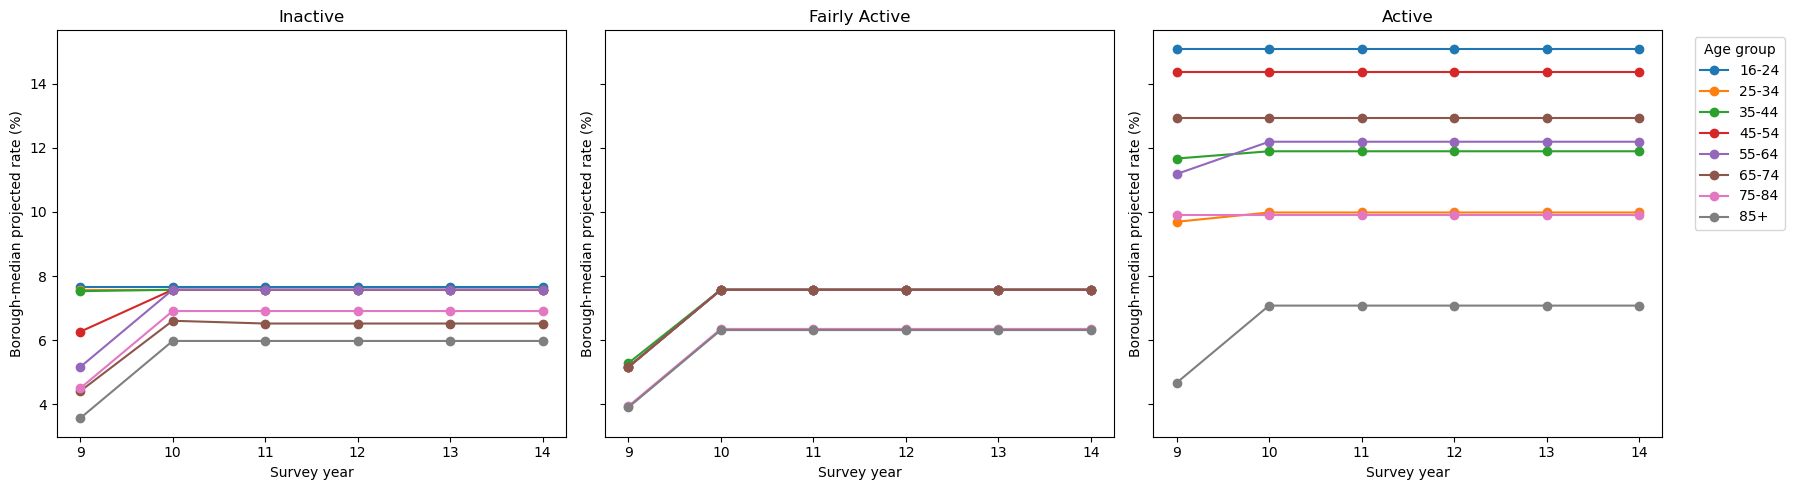

In [32]:
activity_order = [
    "inactive",
    "fairly_active",
    "active",
]

age_order = (
    projection_group_summary[
        [
            "age_group_code",
            "age_group",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "age_group_code"
    )[
        "age_group"
    ]
    .tolist()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5,
    ),
    sharey=True,
)

for axis, activity_level in zip(
    axes,
    activity_order,
):
    activity_data = (
        projection_group_summary.loc[
            projection_group_summary[
                "activity_level_3cat_label"
            ].eq(
                activity_level
            )
        ]
    )

    for age_group in age_order:
        age_data = (
            activity_data.loc[
                activity_data[
                    "age_group"
                ].eq(
                    age_group
                )
            ]
            .sort_values(
                "year"
            )
        )

        axis.plot(
            age_data[
                "year"
            ],
            100
            * age_data[
                "borough_median_rate"
            ],
            marker="o",
            label=age_group,
        )

    axis.set_title(
        activity_level.replace(
            "_",
            " ",
        ).title()
    )

    axis.set_xlabel(
        "Survey year"
    )

    axis.set_ylabel(
        "Borough-median projected rate (%)"
    )

axes[-1].legend(
    title="Age group",
    bbox_to_anchor=(
        1.05,
        1,
    ),
    loc="upper left",
)

fig.tight_layout()

projection_path_figure = (
    FIGURE_DIR
    / "q5_projected_rate_paths.png"
)

fig.savefig(
    projection_path_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

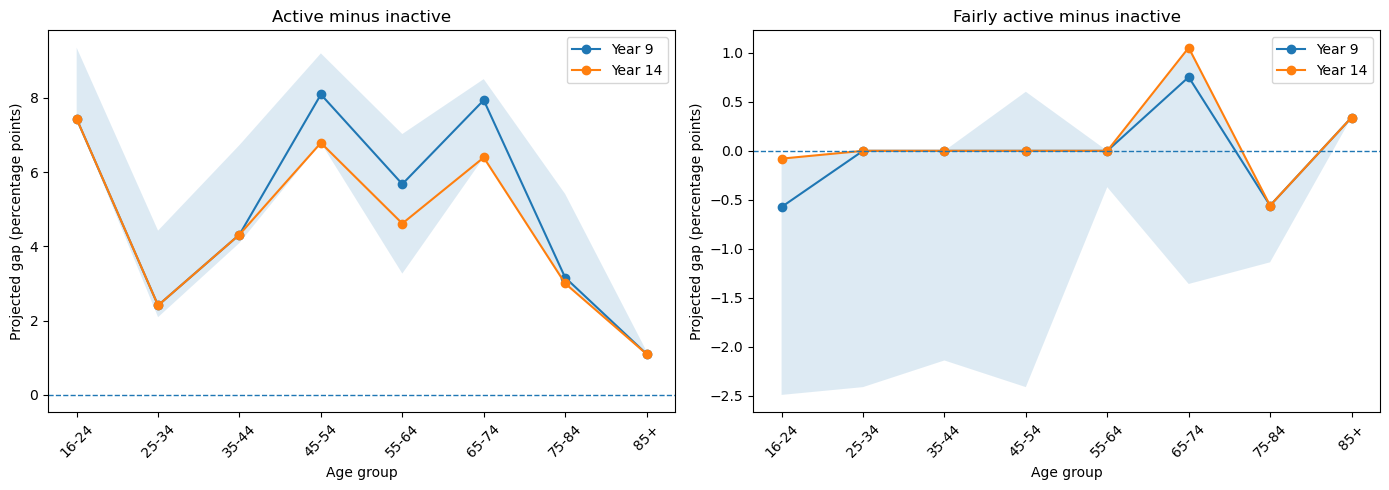

In [33]:
comparison_years = [
    FUTURE_YEARS[0],
    FUTURE_YEARS[-1],
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        14,
        5,
    ),
    sharey=False,
)

for year in comparison_years:
    year_data = (
        gap_age_summary.loc[
            gap_age_summary[
                "year"
            ].eq(
                year
            )
        ]
        .sort_values(
            "age_group_code"
        )
    )

    x_positions = np.arange(
        len(
            year_data
        )
    )

    axes[0].plot(
        x_positions,
        year_data[
            "median_active_minus_inactive_pp"
        ],
        marker="o",
        label=f"Year {year}",
    )

    axes[0].fill_between(
        x_positions,
        year_data[
            "q25_active_minus_inactive_pp"
        ],
        year_data[
            "q75_active_minus_inactive_pp"
        ],
        alpha=0.15,
    )

    axes[1].plot(
        x_positions,
        year_data[
            "median_fairly_active_minus_inactive_pp"
        ],
        marker="o",
        label=f"Year {year}",
    )

    axes[1].fill_between(
        x_positions,
        year_data[
            "q25_fairly_active_minus_inactive_pp"
        ],
        year_data[
            "q75_fairly_active_minus_inactive_pp"
        ],
        alpha=0.15,
    )

for axis in axes:
    axis.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    axis.set_xticks(
        np.arange(
            len(
                age_order
            )
        )
    )

    axis.set_xticklabels(
        age_order,
        rotation=45,
    )

    axis.set_xlabel(
        "Age group"
    )

    axis.set_ylabel(
        "Projected gap "
        "(percentage points)"
    )

    axis.legend()

axes[0].set_title(
    "Active minus inactive"
)

axes[1].set_title(
    "Fairly active minus inactive"
)

fig.tight_layout()

gap_figure_path = (
    FIGURE_DIR
    / "q5_projected_activity_gaps.png"
)

fig.savefig(
    gap_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

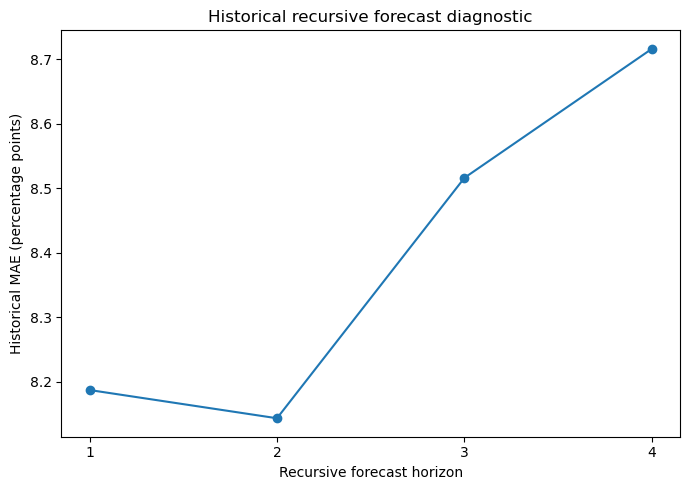

In [34]:
fig, axis = plt.subplots(
    figsize=(
        7,
        5,
    )
)

axis.plot(
    recursive_diagnostic_by_horizon[
        "horizon"
    ],
    100
    * recursive_diagnostic_by_horizon[
        "mae"
    ],
    marker="o",
)

axis.set_xlabel(
    "Recursive forecast horizon"
)

axis.set_ylabel(
    "Historical MAE "
    "(percentage points)"
)

axis.set_title(
    "Historical recursive forecast diagnostic"
)

axis.set_xticks(
    recursive_diagnostic_by_horizon[
        "horizon"
    ]
)

fig.tight_layout()

recursive_figure_path = (
    FIGURE_DIR
    / "q5_recursive_forecast_diagnostic.png"
)

fig.savefig(
    recursive_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

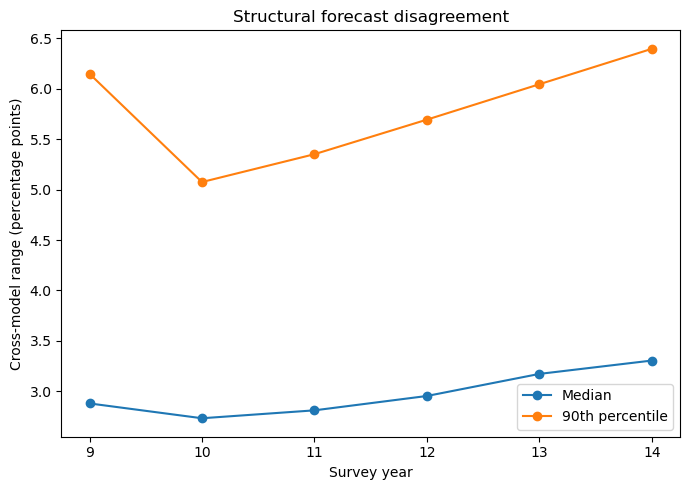

In [35]:
fig, axis = plt.subplots(
    figsize=(
        7,
        5,
    )
)

axis.plot(
    structural_disagreement_summary[
        "year"
    ],
    structural_disagreement_summary[
        "median_cross_model_range_pp"
    ],
    marker="o",
    label="Median",
)

axis.plot(
    structural_disagreement_summary[
        "year"
    ],
    structural_disagreement_summary[
        "q90_cross_model_range_pp"
    ],
    marker="o",
    label="90th percentile",
)

axis.set_xlabel(
    "Survey year"
)

axis.set_ylabel(
    "Cross-model range "
    "(percentage points)"
)

axis.set_title(
    "Structural forecast disagreement"
)

axis.legend()

fig.tight_layout()

structural_figure_path = (
    FIGURE_DIR
    / "q5_structural_disagreement.png"
)

fig.savefig(
    structural_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 14 — Final validation checks

The final checks confirm that the projection outputs preserve the full future borough–age–activity grid, contain no duplicate series-year rows, remain within valid rate bounds and contain all required activity-level contrasts.

In [36]:
expected_future_rows = (
    len(FUTURE_YEARS)
    * len(series_frame)
)

if len(
    future_projections
) != expected_future_rows:
    raise ValueError(
        "Unexpected number of future projection rows"
    )

if future_projections.duplicated(
    subset=[
        "year",
        "series_id",
    ]
).any():
    raise ValueError(
        "Duplicate future series-year rows found"
    )

year_counts = (
    future_projections
    .groupby(
        "year"
    )
    .size()
)

if not year_counts.eq(
    len(
        series_frame
    )
).all():
    raise ValueError(
        "Each future year must contain all 768 series"
    )

if future_projections[
    "predicted_rate"
].isna().any():
    raise ValueError(
        "The selected model produced a missing future projection"
    )

if not future_projections[
    "predicted_rate"
].between(
    PREDICTION_LOWER,
    PREDICTION_UPPER,
).all():
    raise ValueError(
        "A future point projection is outside the valid rate range"
    )

if not future_projections[
    "lower_90"
].between(
    PREDICTION_LOWER,
    PREDICTION_UPPER,
).all():
    raise ValueError(
        "A lower projection bound is invalid"
    )

if not future_projections[
    "upper_90"
].between(
    PREDICTION_LOWER,
    PREDICTION_UPPER,
).all():
    raise ValueError(
        "An upper projection bound is invalid"
    )

if (
    future_projections[
        "lower_90"
    ]
    > future_projections[
        "upper_90"
    ]
).any():
    raise ValueError(
        "A projection interval has reversed bounds"
    )

expected_gap_rows = (
    len(FUTURE_YEARS)
    * 32
    * 8
)

if len(
    activity_level_gaps
) != expected_gap_rows:
    raise ValueError(
        "Unexpected number of projected activity-level gaps"
    )

if activity_level_gaps.duplicated(
    subset=[
        "year",
        "LA_2023",
        "age_group_code",
    ]
).any():
    raise ValueError(
        "Duplicate future borough-age gap rows found"
    )

print(
    f"Future projection rows: "
    f"{len(future_projections):,}"
)

print(
    f"Future gap rows: "
    f"{len(activity_level_gaps):,}"
)

print(
    "All Q5 future-projection checks passed."
)

Future projection rows: 4,608
Future gap rows: 1,536
All Q5 future-projection checks passed.


## 15 — Save the future-projection outputs

The final outputs include cell-level projections, recursive forecast diagnostics, empirical uncertainty summaries, structural sensitivity results and the projected activity-level contrasts.

In [37]:
forecast_summary = {
    "selected_model": (
        SELECTED_MODEL
    ),
    "historical_years": (
        HISTORICAL_YEARS
    ),
    "future_years": (
        FUTURE_YEARS
    ),
    "historical_training_rows": int(
        len(
            final_training_data
        )
    ),
    "future_series_per_year": int(
        len(
            series_frame
        )
    ),
    "future_projection_rows": int(
        len(
            future_projections
        )
    ),
    "simulation_runs": int(
        N_SIMULATIONS
    ),
    "projection_interval": (
        "90% empirical residual-based recursive projection interval"
    ),
    "backtest_origins": (
        BACKTEST_ORIGINS
    ),
    "structural_sensitivity_models": [
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Naive baseline",
    ],
}

output_tables = {
    "q5_future_cell_projections.csv": (
        future_projections
    ),
    "q5_recursive_backtest_predictions.csv": (
        recursive_backtest_predictions
    ),
    "q5_recursive_diagnostic_by_origin.csv": (
        recursive_diagnostic_by_origin
    ),
    "q5_recursive_diagnostic_by_horizon.csv": (
        recursive_diagnostic_by_horizon
    ),
    "q5_residual_pool_diagnostics.csv": (
        residual_pool_diagnostics
    ),
    "q5_interval_summary.csv": (
        interval_summary
    ),
    "q5_structural_sensitivity_projections.csv": (
        structural_sensitivity_projections
    ),
    "q5_structural_behaviour_summary.csv": (
        structural_behaviour_summary
    ),
    "q5_structural_disagreement_summary.csv": (
        structural_disagreement_summary
    ),
    "q5_activity_level_gaps.csv": (
        activity_level_gaps
    ),
    "q5_projection_group_summary.csv": (
        projection_group_summary
    ),
    "q5_gap_age_summary.csv": (
        gap_age_summary
    ),
    "q5_change_from_year8_summary.csv": (
        change_from_year8_summary
    ),
}

for filename, dataframe in (
    output_tables.items()
):
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )

summary_path = (
    OUTPUT_DIR
    / "q5_future_projection_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        forecast_summary,
        file,
        indent=2,
    )

print(
    f"Saved projection summary: "
    f"{summary_path}"
)

Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_future_cell_projections.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_recursive_backtest_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_recursive_diagnostic_by_origin.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_recursive_diagnostic_by_horizon.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_residual_pool_diagnostics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_interval_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_structural_sensitivity_projections.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_future_forecasting_outputs/tables/q5_structural_behaviour_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/